# MLflow con Optuna: Optimización y Seguimiento de Hiperparámetros

Una parte crítica de la construcción de modelos de calidad para producción es asegurar que los parámetros de un modelo dado se seleccionen para crear el mejor conjunto de inferencias posible. Sin embargo, la gran cantidad de combinaciones y sus métricas resultantes pueden volverse abrumadoras de rastrear manualmente. Ahí es donde entran en juego herramientas como MLflow y Optuna.

### Objetivo: 
En este notebook, aprenderás cómo integrar MLflow con Optuna para la optimización de hiperparámetros. Te guiaremos a través del proceso de:

* Configurar tu entorno con el seguimiento de MLflow.
* Generar nuestros conjuntos de datos de entrenamiento y evaluación.
* Definir una función parcial que ajusta un modelo de aprendizaje automático.
* Usar Optuna para el ajuste de hiperparámetros.
* Aprovechar las ejecuciones hijas dentro de MLflow para llevar un registro de cada iteración durante el proceso de ajuste de hiperparámetros.

### ¿Por qué Optuna?
Optuna es un framework de código abierto para optimización de hiperparámetros en Python. Proporciona un enfoque eficiente para buscar entre hiperparámetros, incorporando las últimas investigaciones y técnicas. Con su integración en MLflow, cada prueba puede ser registrada sistemáticamente.

### Ejecuciones Hijas en MLflow:
Una de las características centrales que enfatizaremos es el concepto de 'ejecuciones hijas' en MLflow. Al realizar el ajuste de hiperparámetros, cada iteración (o prueba) en Optuna puede considerarse una 'ejecución hija'. Esto nos permite agrupar todas las ejecuciones bajo una 'ejecución padre' principal, asegurando que la interfaz de MLflow permanezca organizada e interpretable. Cada ejecución hija rastreará los hiperparámetros específicos utilizados y las métricas resultantes, proporcionando una vista consolidada de todo el proceso de optimización.

### ¿Qué Viene Después?

**Preparación de Datos**: Comenzaremos cargando y preprocesando nuestro conjunto de datos.

**Definición del Modelo**: Definir un modelo de aprendizaje automático que queremos optimizar.

**Estudio Optuna**: Configurar un estudio Optuna para encontrar los mejores hiperparámetros para nuestro modelo.

**Integración MLflow**: Rastrear cada prueba de Optuna como una ejecución hija en MLflow.

**Análisis**: Revisar los resultados rastreados en la interfaz de MLflow.

Al final de este notebook, tendrás experiencia práctica en la configuración de un flujo de trabajo avanzado de ajuste de hiperparámetros, enfatizando las mejores prácticas y la organización limpia usando MLflow y Optuna. 

**¡Comencemos!**

In [1]:
import math
from datetime import datetime, timedelta

import numpy as np
import optuna
import pandas as pd
import xgboost as xgb
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

import mlflow

### Configurar la URI del servidor de seguimiento

Dependiendo de dónde estés ejecutando este notebook, tu configuración puede variar en cómo inicializas la interfaz con el Servidor de Seguimiento de MLflow. 

Para este ejemplo, estamos usando un servidor de seguimiento ejecutándose localmente, pero hay otras opciones disponibles (La más fácil es usar el servicio gestionado gratuito dentro de [Databricks Free Trial](https://mlflow.org/docs/latest/getting-started/databricks-trial.html)). 

Por favor consulta [la guía para ejecutar notebooks aquí](https://www.mlflow.org/docs/latest/getting-started/running-notebooks/) para más información sobre cómo configurar la URI del servidor de seguimiento y configurar el acceso a servidores de seguimiento MLflow gestionados o autogestionados.

In [2]:
# NOTE: review the links mentioned above for guidance on connecting to a managed tracking server, such as the Databricks managed MLflow

mlflow.set_tracking_uri("http://localhost:8080")

### Generar nuestros datos de entrenamiento sintéticos

Si has seguido el tutorial introductorio "Registrando tu primer modelo con MLflow", entonces estás familiarizado con el generador de datos de ventas de manzanas que creamos para ese tutorial. 

Aquí, estamos expandiendo los datos para crear un conjunto de datos ligeramente más complejo que debería tener efectos de correlación mejorados entre las características y la variable objetivo (la demanda). 

In [3]:
def generate_apple_sales_data_with_promo_adjustment(
    base_demand: int = 1000,
    n_rows: int = 5000,
    competitor_price_effect: float = -50.0,
):
    """
    Generates a synthetic dataset for predicting apple sales demand with multiple
    influencing factors.

    This function creates a pandas DataFrame with features relevant to apple sales.
    The features include date, average_temperature, rainfall, weekend flag, holiday flag,
    promotional flag, price_per_kg, competitor's price, marketing intensity, stock availability,
    and the previous day's demand. The target variable, 'demand', is generated based on a
    combination of these features with some added noise.

    Args:
        base_demand (int, optional): Base demand for apples. Defaults to 1000.
        n_rows (int, optional): Number of rows (days) of data to generate. Defaults to 5000.
        competitor_price_effect (float, optional): Effect of competitor's price being lower
                                                   on our sales. Defaults to -50.

    Returns:
        pd.DataFrame: DataFrame with features and target variable for apple sales prediction.

    Example:
        >>> df = generate_apple_sales_data_with_promo_adjustment(base_demand=1200, n_rows=6000)
        >>> df.head()
    """

    # Set seed for reproducibility
    np.random.seed(9999)

    # Create date range
    dates = [datetime.now() - timedelta(days=i) for i in range(n_rows)]
    dates.reverse()

    # Generate features
    df = pd.DataFrame(
        {
            "date": dates,
            "average_temperature": np.random.uniform(10, 35, n_rows),
            "rainfall": np.random.exponential(5, n_rows),
            "weekend": [(date.weekday() >= 5) * 1 for date in dates],
            "holiday": np.random.choice([0, 1], n_rows, p=[0.97, 0.03]),
            "price_per_kg": np.random.uniform(0.5, 3, n_rows),
            "month": [date.month for date in dates],
        }
    )

    # Introduce inflation over time (years)
    df["inflation_multiplier"] = 1 + (df["date"].dt.year - df["date"].dt.year.min()) * 0.03

    # Incorporate seasonality due to apple harvests
    df["harvest_effect"] = np.sin(2 * np.pi * (df["month"] - 3) / 12) + np.sin(
        2 * np.pi * (df["month"] - 9) / 12
    )

    # Modify the price_per_kg based on harvest effect
    df["price_per_kg"] = df["price_per_kg"] - df["harvest_effect"] * 0.5

    # Adjust promo periods to coincide with periods lagging peak harvest by 1 month
    peak_months = [4, 10]  # months following the peak availability
    df["promo"] = np.where(
        df["month"].isin(peak_months),
        1,
        np.random.choice([0, 1], n_rows, p=[0.85, 0.15]),
    )

    # Generate target variable based on features
    base_price_effect = -df["price_per_kg"] * 50
    seasonality_effect = df["harvest_effect"] * 50
    promo_effect = df["promo"] * 200

    df["demand"] = (
        base_demand
        + base_price_effect
        + seasonality_effect
        + promo_effect
        + df["weekend"] * 300
        + np.random.normal(0, 50, n_rows)
    ) * df["inflation_multiplier"]  # adding random noise

    # Add previous day's demand
    df["previous_days_demand"] = df["demand"].shift(1)
    df["previous_days_demand"].fillna(method="bfill", inplace=True)  # fill the first row

    # Introduce competitor pricing
    df["competitor_price_per_kg"] = np.random.uniform(0.5, 3, n_rows)
    df["competitor_price_effect"] = (
        df["competitor_price_per_kg"] < df["price_per_kg"]
    ) * competitor_price_effect

    # Stock availability based on past sales price (3 days lag with logarithmic decay)
    log_decay = -np.log(df["price_per_kg"].shift(3) + 1) + 2
    df["stock_available"] = np.clip(log_decay, 0.7, 1)

    # Marketing intensity based on stock availability
    # Identify where stock is above threshold
    high_stock_indices = df[df["stock_available"] > 0.95].index

    # For each high stock day, increase marketing intensity for the next week
    for idx in high_stock_indices:
        df.loc[idx : min(idx + 7, n_rows - 1), "marketing_intensity"] = np.random.uniform(0.7, 1)

    # If the marketing_intensity column already has values, this will preserve them;
    #  if not, it sets default values
    fill_values = pd.Series(np.random.uniform(0, 0.5, n_rows), index=df.index)
    df["marketing_intensity"].fillna(fill_values, inplace=True)

    # Adjust demand with new factors
    df["demand"] = df["demand"] + df["competitor_price_effect"] + df["marketing_intensity"]

    # Drop temporary columns
    df.drop(
        columns=[
            "inflation_multiplier",
            "harvest_effect",
            "month",
            "competitor_price_effect",
            "stock_available",
        ],
        inplace=True,
    )

    return df

In [4]:
df = generate_apple_sales_data_with_promo_adjustment(base_demand=1_000, n_rows=5000)
df

,date,average_temperature,rainfall,weekend,holiday,price_per_kg,promo,demand,previous_days_demand,competitor_price_per_kg,marketing_intensity
0,2010-01-14 11:52:20.662955,30.584727,1.199291,0,0,1.726258,0,851.375336,851.276659,1.935346,0.098677
1,2010-01-15 11:52:20.662954,15.465069,1.037626,0,0,0.576471,0,906.855943,851.276659,2.344720,0.019318
2,2010-01-16 11:52:20.662954,10.786525,5.656089,1,0,2.513328,0,1108.304909,906.836626,0.998803,0.409485
3,2010-01-17 11:52:20.662953,23.648154,12.030937,1,0,1.839225,0,1099.833810,1157.895424,0.761740,0.872803
4,2010-01-18 11:52:20.662952,13.861391,4.303812,0,0,1.531772,0,983.949061,1148.961007,2.123436,0.820779
...,...,...,...,...,...,...,...,...,...,...,...
4995,2023-09-18 11:52:20.659592,21.643051,3.821656,0,0,2.391010,0,1140.210762,1563.064082,1.504432,0.756489
4996,2023-09-19 11:52:20.659591,13.808813,1.080603,0,1,0.898693,0,1285.149505,1189.454273,1.343586,0.742145
4997,2023-09-20 11:52:20.659590,11.698227,1.911000,0,0,2.839860,0,965.171368,1284.407359,2.771896,0.742145
4998,2023-09-21 11:52:20.659589,18.052081,1.000521,0,0,1.188440,0,1368.369501,1014.429223,2.564075,0.742145


### Examinando las Correlaciones entre Características y Objetivo

Antes de profundizar en el proceso de construcción del modelo, es esencial entender las relaciones entre nuestras características y la variable objetivo. La próxima función mostrará un gráfico que indica el coeficiente de correlación para cada característica en relación con el objetivo. Aquí está por qué este paso es crucial:

1. **Evitar Fuga de Datos**: Debemos asegurar que ninguna característica se correlacione perfectamente con el objetivo (un coeficiente de correlación de 1.0). Si existe tal correlación, es una señal de que nuestro conjunto de datos podría estar "filtrando" información sobre el objetivo. Usar tales datos para el ajuste de hiperparámetros engañaría al modelo, ya que podría lograr fácilmente una puntuación perfecta sin aprender genuinamente los patrones subyacentes.

2. **Asegurar Relaciones Significativas**: Idealmente, nuestras características deberían tener algún grado de correlación con el objetivo. Si todas las características tienen coeficientes de correlación cercanos a cero, sugiere una relación lineal débil. Aunque esto no hace que las características sean automáticamente inútiles, sí introduce desafíos:
    * *Poder Predictivo*: El modelo podría tener dificultades para hacer predicciones precisas.
    * *Riesgo de Sobreajuste*: Con correlaciones débiles, hay un mayor riesgo de que el modelo se ajuste al ruido en lugar de a patrones genuinos, lo que lleva al sobreajuste.
    * *Complejidad*: Demostrar relaciones no lineales o interacciones entre características necesitaría visualizaciones y evaluaciones más intrincadas.
3. **Auditoría y Trazabilidad**: Registrar esta visualización de correlación con nuestra ejecución principal de MLflow asegura trazabilidad. Proporciona una instantánea de las características de los datos en el momento del entrenamiento del modelo, lo cual es invaluable para propósitos de auditoría y replicabilidad.

Mientras procedemos, recuerda que aunque entender las correlaciones es una herramienta poderosa, es solo una pieza del rompecabezas. ¡Visualicemos estas relaciones para obtener más información!

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot_correlation_with_demand(df, save_path=None):
    """
    Plots the correlation of each variable in the dataframe with the 'demand' column.

    Args:
    - df (pd.DataFrame): DataFrame containing the data, including a 'demand' column.
    - save_path (str, optional): Path to save the generated plot. If not specified, plot won't be saved.

    Returns:
    - None (Displays the plot on a Jupyter window)
    """

    # Compute correlations between all variables and 'demand'
    correlations = df.corr()["demand"].drop("demand").sort_values()

    # Generate a color palette from red to green
    colors = sns.diverging_palette(10, 130, as_cmap=True)
    color_mapped = correlations.map(colors)

    # Set Seaborn style
    sns.set_style(
        "whitegrid", {"axes.facecolor": "#c2c4c2", "grid.linewidth": 1.5}
    )  # Light grey background and thicker grid lines

    # Create bar plot
    fig = plt.figure(figsize=(12, 8))
    plt.barh(correlations.index, correlations.values, color=color_mapped)

    # Set labels and title with increased font size
    plt.title("Correlation with Demand", fontsize=18)
    plt.xlabel("Correlation Coefficient", fontsize=16)
    plt.ylabel("Variable", fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.grid(axis="x")

    plt.tight_layout()

    # Save the plot if save_path is specified
    if save_path:
        plt.savefig(save_path, format="png", dpi=600)

    # prevent matplotlib from displaying the chart every time we call this function
    plt.close(fig)

    return fig


# Test the function
correlation_plot = plot_correlation_with_demand(df, save_path="correlation_plot.png")

<Figure size 432x288 with 0 Axes>

#### Investigando la Correlación de Características con la Variable Objetivo

En el código anterior, hemos deshabilitado intencionalmente la visualización automática del gráfico generado por Matplotlib. Durante la experimentación de aprendizaje automático, a menudo no es útil mostrar figuras directamente dentro del notebook por varias razones. En su lugar, buscamos asociar este gráfico con los resultados de una ejecución de experimento iterativa. Para lograr esto, guardaremos el gráfico en nuestro sistema de seguimiento MLflow. Esto nos proporciona un registro detallado, vinculando el estado del conjunto de datos con el modelo registrado, sus parámetros y métricas de rendimiento.

##### ¿Por qué No Mostrar Gráficos Directamente en el Notebook?

Elegir no mostrar gráficos dentro del notebook es una decisión deliberada, y las razones son múltiples. Algunos de los puntos clave incluyen:

- **Naturaleza Efímera de los Notebooks**: Los notebooks son inherentemente transitorios; no están diseñados para ser un registro permanente de tu trabajo.
  
- **Riesgo de Obsolescencia**: Si vuelves a ejecutar porciones de tu notebook, el gráfico mostrado podría volverse obsoleto o engañoso, planteando un riesgo al interpretar resultados.
  
- **Pérdida de Estado Previo**: Si vuelves a ejecutar todo el notebook, el gráfico se perderá. Aunque algunos plugins pueden recuperar estados previos de celdas, configurar esto puede ser engorroso y consumir tiempo.

En contraste, registrar el gráfico en MLflow asegura que tengamos un registro permanente y fácilmente accesible que se correlaciona directamente con otros datos del experimento. Esto es invaluable para mantener la integridad y reproducibilidad de tus experimentos de aprendizaje automático.

##### Mostrando el Gráfico para Esta Guía

Para los propósitos de esta guía, aún tomaremos un momento para examinar el gráfico. Podemos hacer esto llamando explícitamente al objeto de figura que hemos retornado de nuestra función.


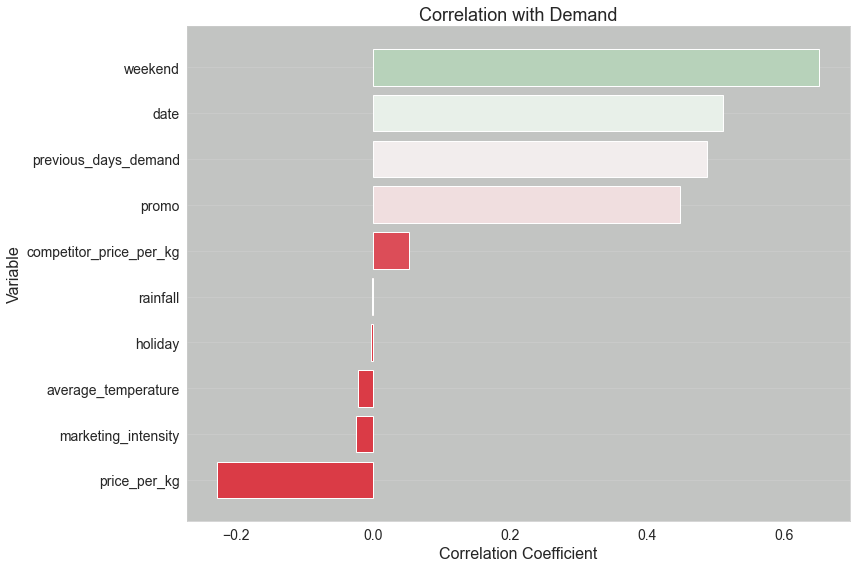

In [6]:
correlation_plot

#### Visualizando Residuos del Modelo para Información Diagnóstica

La función `plot_residuals` sirve para visualizar los residuos—las diferencias entre las predicciones del modelo y los valores reales en el conjunto de validación. Los gráficos de residuos son herramientas diagnósticas cruciales en aprendizaje automático, ya que pueden revelar patrones que sugieren que nuestro modelo está fallando en capturar algún aspecto de los datos o que hay un problema sistemático con el modelo mismo.

##### ¿Por qué Gráficos de Residuos?

Los gráficos de residuos ofrecen varias ventajas:

- **Identificar Sesgo**: Si los residuos muestran una tendencia (no centrados alrededor de cero), podría indicar que tu modelo está sistemáticamente sobre-prediciendo o sub-prediciendo la variable objetivo.

- **Heterocedasticidad**: La variación de la dispersión de residuos a lo largo del rango de valores predichos puede indicar 'Heterocedasticidad', que puede violar suposiciones en algunas técnicas de modelado.

- **Valores Atípicos**: Puntos alejados de la línea cero pueden ser considerados como valores atípicos y podrían merecer mayor investigación.

##### Guardado Automático del Gráfico

Al igual que con el gráfico de correlación, esta función te permite guardar el gráfico de residuos en una ruta específica. Esta característica se alinea con nuestra estrategia más amplia de registrar figuras importantes en MLflow para un seguimiento y auditoría de modelos más efectivos.

##### Estructura del Gráfico

En el gráfico de dispersión, cada punto representa el residuo para una observación específica en el conjunto de validación. La línea horizontal roja en cero sirve como referencia, indicando dónde estarían los residuos si las predicciones del modelo fueran perfectas.

Para los propósitos de esta guía, estaremos generando este gráfico, pero no lo examinaremos hasta más tarde cuando lo veamos dentro de la interfaz de MLflow.


In [7]:
def plot_residuals(model, dvalid, valid_y, save_path=None):
    """
    Plots the residuals of the model predictions against the true values.

    Args:
    - model: The trained XGBoost model.
    - dvalid (xgb.DMatrix): The validation data in XGBoost DMatrix format.
    - valid_y (pd.Series): The true values for the validation set.
    - save_path (str, optional): Path to save the generated plot. If not specified, plot won't be saved.

    Returns:
    - None (Displays the residuals plot on a Jupyter window)
    """

    # Predict using the model
    preds = model.predict(dvalid)

    # Calculate residuals
    residuals = valid_y - preds

    # Set Seaborn style
    sns.set_style("whitegrid", {"axes.facecolor": "#c2c4c2", "grid.linewidth": 1.5})

    # Create scatter plot
    fig = plt.figure(figsize=(12, 8))
    plt.scatter(valid_y, residuals, color="blue", alpha=0.5)
    plt.axhline(y=0, color="r", linestyle="-")

    # Set labels, title and other plot properties
    plt.title("Residuals vs True Values", fontsize=18)
    plt.xlabel("True Values", fontsize=16)
    plt.ylabel("Residuals", fontsize=16)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.grid(axis="y")

    plt.tight_layout()

    # Save the plot if save_path is specified
    if save_path:
        plt.savefig(save_path, format="png", dpi=600)

    # Show the plot
    plt.close(fig)

    return fig

#### Entendiendo la Importancia de Características con XGBoost

La función `plot_feature_importance` está diseñada para visualizar la importancia de cada característica utilizada en nuestro modelo XGBoost. Entender la importancia de las características puede ofrecer información crítica sobre el proceso de toma de decisiones del modelo y puede ayudar en la selección, ingeniería e interpretación de características.

##### Tipos de Importancia de Características

XGBoost ofrece múltiples formas de interpretar la importancia de las características. Esta función soporta:

- **Weight**: Número de veces que una característica aparece en un árbol a través del conjunto de árboles (para el booster `gblinear`).
- **Gain**: Ganancia promedio (o mejora al modelo) de la característica cuando se usa en los árboles (para otros tipos de booster).

Automáticamente seleccionamos el tipo de importancia apropiado basado en el booster usado en el modelo XGBoost.

##### Por qué Importa la Importancia de Características

Entender la importancia de características ofrece varias ventajas:

- **Interpretabilidad**: Saber qué características son más influyentes nos ayuda a entender mejor el modelo.
- **Selección de Características**: Las características no importantes pueden potencialmente eliminarse para simplificar el modelo.
- **Comprensión del Dominio**: Alinea la escala de importancia del modelo con el conocimiento o intuición específica del dominio.

##### Guardando y Accediendo al Gráfico

Esta función devuelve un objeto de figura de Matplotlib que puedes manipular o guardar aún más. Como los gráficos anteriores, es aconsejable registrar este gráfico en MLflow para un registro inmutable de las características interpretativas de tu modelo.

##### Navegando el Gráfico

En el gráfico resultante, cada barra representa una característica usada en el modelo. La longitud de la barra corresponde a la importancia de la característica, según el tipo de importancia seleccionado.

Necesitamos un modelo entrenado para generar este gráfico. Como tal, estaremos generando, pero no mostrando el gráfico cuando entrenemos el modelo. La figura resultante será registrada en MLflow y visible dentro de la interfaz. 


In [8]:
def plot_feature_importance(model, booster):
    """
    Plots feature importance for an XGBoost model.

    Args:
    - model: A trained XGBoost model

    Returns:
    - fig: The matplotlib figure object
    """
    fig, ax = plt.subplots(figsize=(10, 8))
    importance_type = "weight" if booster == "gblinear" else "gain"
    xgb.plot_importance(
        model,
        importance_type=importance_type,
        ax=ax,
        title=f"Feature Importance based on {importance_type}",
    )
    plt.tight_layout()
    plt.close(fig)

    return fig

### Configurando el Experimento de MLflow

Antes de comenzar nuestro proceso de ajuste de hiperparámetros, necesitamos designar un "experimento" específico dentro de MLflow para rastrear y registrar nuestros resultados. Un experimento en MLflow es esencialmente un conjunto nombrado de ejecuciones. Cada ejecución dentro de un experimento rastrea sus propios parámetros, métricas, etiquetas y artefactos.

#### ¿Por qué crear un nuevo experimento?

1. **Organización**: Ayuda a mantener nuestras ejecuciones organizadas bajo una tarea o proyecto específico, haciendo más fácil comparar y analizar resultados.
2. **Aislamiento**: Al aislar diferentes tareas o proyectos en experimentos separados, prevenimos sobrescrituras accidentales o malas interpretaciones de resultados.

La función `get_or_create_experiment` que hemos definido a continuación ayuda en este proceso. Verifica si un experimento con el nombre especificado ya existe. Si es así, recupera su ID. Si no, crea un nuevo experimento y devuelve su ID.

#### ¿Cómo usaremos el experiment_id?
El experiment_id recuperado o creado se vuelve crucial cuando iniciamos nuestro ajuste de hiperparámetros. Al iniciar la ejecución padre para el ajuste, el experiment_id asegura que la ejecución, junto con sus ejecuciones hijas anidadas, se registre bajo el experimento correcto. Proporciona una forma estructurada de navegar, comparar y analizar nuestros resultados de ajuste dentro de la interfaz de MLflow.

Cuando queremos probar rangos de parámetros adicionales, diferentes parámetros o un conjunto de datos ligeramente modificado, podemos usar este Experimento para registrar todas las ejecuciones padre y mantener nuestra interfaz de Seguimiento de MLflow limpia y fácil de navegar.

¡Procedamos y configuremos nuestro experimento!

In [9]:
def get_or_create_experiment(experiment_name):
    """
    Retrieve the ID of an existing MLflow experiment or create a new one if it doesn't exist.

    This function checks if an experiment with the given name exists within MLflow.
    If it does, the function returns its ID. If not, it creates a new experiment
    with the provided name and returns its ID.

    Parameters:
    - experiment_name (str): Name of the MLflow experiment.

    Returns:
    - str: ID of the existing or newly created MLflow experiment.
    """

    if experiment := mlflow.get_experiment_by_name(experiment_name):
        return experiment.experiment_id
    else:
        return mlflow.create_experiment(experiment_name)

#### Crear un experimento para nuestras ejecuciones de ajuste de hiperparámetros

In [10]:
experiment_id = get_or_create_experiment("Apples Demand")

Podemos ver el `experiment_id` que fue generado o recuperado para ver cómo se ve esta clave de referencia única. El valor generado aquí también es visible dentro de la interfaz de MLflow.

In [11]:
experiment_id

'908436739760555869'

#### Configurando MLflow y Preprocesamiento de Datos para Entrenamiento del Modelo

Esta sección del código logra dos tareas principales: inicializar un experimento de MLflow para uso en el seguimiento de ejecuciones y preparar el conjunto de datos para entrenamiento y validación del modelo.

##### Inicialización de MLflow

Comenzamos configurando el experimento de MLflow usando la función `set_experiment`. El `experiment_id` sirve como un identificador único para el experimento, permitiéndonos segregar y gestionar diferentes ejecuciones y sus datos asociados eficientemente.

##### Preprocesamiento de Datos

Los siguientes pasos involucran preparar el conjunto de datos para el entrenamiento del modelo:

1. **Selección de Características**: Eliminamos las columnas 'date' y 'demand' de nuestro DataFrame, reteniendo solo las columnas de características en `X`.
  
2. **Variable Objetivo**: La columna 'demand' es designada como nuestra variable objetivo `y`.

3. **División de Datos**: Dividimos el conjunto de datos en conjuntos de entrenamiento (`train_x`, `train_y`) y validación (`valid_x`, `valid_y`) usando una división 75-25.

4. **Formato de Datos XGBoost**: Finalmente, convertimos los conjuntos de datos de entrenamiento y validación al formato DMatrix de XGBoost. Esta estructura de datos optimizada acelera el proceso de entrenamiento y es requerida para usar las funcionalidades avanzadas de XGBoost.

##### Por qué Estos Pasos Importan

- **Seguimiento MLflow**: Inicializar el experimento de MLflow asegura que todas las ejecuciones subsecuentes del modelo, métricas y artefactos se registren bajo el mismo experimento, haciendo más fácil comparar y analizar diferentes modelos. Aunque estamos usando la ``API fluida`` para hacer esto aquí, también puedes especificar el ``experiment_id`` dentro de un contexto ``start_run()``.

- **Preparación de Datos**: Preparar adecuadamente tus datos asegura que el proceso de entrenamiento del modelo procederá sin problemas y que los resultados serán tan precisos como sea posible.

En los siguientes pasos, procederemos al entrenamiento y evaluación del modelo, y todos estos pasos de preparación entrarán en juego.


In [12]:
# Set the current active MLflow experiment
mlflow.set_experiment(experiment_id=experiment_id)

# Preprocess the dataset
X = df.drop(columns=["date", "demand"])
y = df["demand"]
train_x, valid_x, train_y, valid_y = train_test_split(X, y, test_size=0.25)
dtrain = xgb.DMatrix(train_x, label=train_y)
dvalid = xgb.DMatrix(valid_x, label=valid_y)

#### Ajuste de Hiperparámetros y Entrenamiento del Modelo usando Optuna y MLflow

La función `objective` sirve como el núcleo de nuestro proceso de ajuste de hiperparámetros usando Optuna. Adicionalmente, entrena un modelo XGBoost usando los hiperparámetros seleccionados y registra métricas y parámetros en MLflow.

##### Ejecuciones Anidadas de MLflow

La función inicia una nueva ejecución anidada en MLflow. Las ejecuciones anidadas son útiles para organizar experimentos de ajuste de hiperparámetros ya que te permiten agrupar ejecuciones individuales bajo una ejecución padre.

##### Definiendo Hiperparámetros

Los métodos `trial.suggest_*` de Optuna se usan para definir un rango de valores posibles para hiperparámetros. Aquí está lo que hace cada hiperparámetro:

- `objective` y `eval_metric`: Definen la función de pérdida y la métrica de evaluación.
- `booster`: Tipo de boosting a usar (`gbtree`, `gblinear`, o `dart`).
- `lambda` y `alpha`: Parámetros de regularización.
- Parámetros adicionales como `max_depth`, `eta` y `gamma` son específicos para modelos basados en árboles (`gbtree` y `dart`).

##### Entrenamiento del Modelo

Un modelo XGBoost es entrenado usando los hiperparámetros elegidos y el conjunto de datos de entrenamiento preprocesado (`dtrain`). Las predicciones se hacen en el conjunto de validación (`dvalid`), y se calcula el error cuadrático medio (`mse`).

##### Registro con MLflow

Todos los hiperparámetros seleccionados y métricas (`mse` y `rmse`) se registran en MLflow para análisis y comparación posteriores.

- `mlflow.log_params`: Registra los hiperparámetros.
- `mlflow.log_metric`: Registra las métricas.

##### Por qué Esta Función es Importante

- **Ajuste Automatizado**: Optuna automatiza el proceso de encontrar los mejores hiperparámetros.
- **Seguimiento de Experimentos**: MLflow nos permite llevar un registro de los hiperparámetros y métricas de rendimiento de cada ejecución, haciendo más fácil analizar, comparar y reproducir experimentos más tarde.

En el siguiente paso, esta función objetivo será usada por Optuna para encontrar el conjunto óptimo de hiperparámetros para nuestro modelo XGBoost.


#### Mantenimiento: Optimizando el Registro para Pruebas de Optuna

Mientras nos embarcamos en nuestro viaje de ajuste de hiperparámetros con Optuna, es esencial entender que el proceso puede generar una multitud de ejecuciones. De hecho, tantas que la salida estándar (stdout) del logger predeterminado puede inundarse rápidamente, produciendo páginas y páginas de reportes de registro.

Aunque la verbosidad de la configuración de registro predeterminada es innegablemente valiosa durante la fase de desarrollo de código, iniciar una prueba a gran escala puede resultar en una cantidad abrumadora de información. Considerando esto, registrar cada detalle en stdout se vuelve menos práctico, especialmente cuando tenemos herramientas dedicadas como MLflow para rastrear meticulosamente nuestros experimentos.

Para lograr un equilibrio, utilizaremos callbacks para adaptar nuestro comportamiento de registro.

##### Implementando un Callback de Registro:

El callback que estamos a punto de introducir modificará el comportamiento de reporte predeterminado. En lugar de registrar cada prueba, solo recibiremos actualizaciones cuando una nueva combinación de hiperparámetros produzca una mejora sobre el mejor valor de métrica registrado hasta ahora.

Este enfoque ofrece dos beneficios destacados:

1. **Legibilidad Mejorada**: Al filtrar los extensos detalles de registro y enfocarnos solo en las pruebas que muestran mejora, podemos evaluar la eficacia de nuestra búsqueda de hiperparámetros. Por ejemplo, si observamos una frecuencia decreciente de reportes de 'mejor resultado' temprano, podría sugerir que menos iteraciones serían suficientes para identificar un conjunto óptimo de hiperparámetros. Por otro lado, una tasa constante de mejora podría indicar que nuestro conjunto de características requiere mayor refinamiento.
   
2. **Indicadores de Progreso**: Especialmente pertinente para pruebas extensas que abarcan horas o incluso días, recibir actualizaciones periódicas proporciona seguridad de que el proceso aún está en movimiento. Estas notificaciones de 'latido' afirman que nuestro sistema está trabajando diligentemente, incluso si no está inundando stdout con cada detalle minucioso.

Además, la interfaz de usuario (UI) de MLflow complementa esta estrategia. A medida que concluye cada prueba, MLflow registra la ejecución hija, haciéndola accesible bajo el paraguas de la ejecución padre.

En el código siguiente:

1. Ajustamos el nivel de registro de Optuna para reportar solo errores, asegurando un stdout despejado.
2. Definimos una función `champion_callback`, adaptada para registrar solo cuando una prueba supera la métrica mejor registrada previamente.

Profundicemos en la implementación:


In [13]:
# override Optuna's default logging to ERROR only
optuna.logging.set_verbosity(optuna.logging.ERROR)

# define a logging callback that will report on only new challenger parameter configurations if a
# trial has usurped the state of 'best conditions'


def champion_callback(study, frozen_trial):
    """
    Logging callback that will report when a new trial iteration improves upon existing
    best trial values.

    Note: This callback is not intended for use in distributed computing systems such as Spark
    or Ray due to the micro-batch iterative implementation for distributing trials to a cluster's
    workers or agents.
    The race conditions with file system state management for distributed trials will render
    inconsistent values with this callback.
    """

    winner = study.user_attrs.get("winner", None)

    if study.best_value and winner != study.best_value:
        study.set_user_attr("winner", study.best_value)
        if winner:
            improvement_percent = (abs(winner - study.best_value) / study.best_value) * 100
            print(
                f"Trial {frozen_trial.number} achieved value: {frozen_trial.value} with "
                f"{improvement_percent: .4f}% improvement"
            )
        else:
            print(f"Initial trial {frozen_trial.number} achieved value: {frozen_trial.value}")

In [14]:
def objective(trial):
    with mlflow.start_run(nested=True):
        # Define hyperparameters
        params = {
            "objective": "reg:squarederror",
            "eval_metric": "rmse",
            "booster": trial.suggest_categorical("booster", ["gbtree", "gblinear", "dart"]),
            "lambda": trial.suggest_float("lambda", 1e-8, 1.0, log=True),
            "alpha": trial.suggest_float("alpha", 1e-8, 1.0, log=True),
        }

        if params["booster"] == "gbtree" or params["booster"] == "dart":
            params["max_depth"] = trial.suggest_int("max_depth", 1, 9)
            params["eta"] = trial.suggest_float("eta", 1e-8, 1.0, log=True)
            params["gamma"] = trial.suggest_float("gamma", 1e-8, 1.0, log=True)
            params["grow_policy"] = trial.suggest_categorical(
                "grow_policy", ["depthwise", "lossguide"]
            )

        # Train XGBoost model
        bst = xgb.train(params, dtrain)
        preds = bst.predict(dvalid)
        error = mean_squared_error(valid_y, preds)

        # Log to MLflow
        mlflow.log_params(params)
        mlflow.log_metric("mse", error)
        mlflow.log_metric("rmse", math.sqrt(error))

    return error

#### Orquestando Ajuste de Hiperparámetros, Entrenamiento de Modelo y Registro con MLflow

Esta sección del código sirve como la capa de orquestación, reuniendo Optuna para ajuste de hiperparámetros y MLflow para seguimiento de experimentos.

##### Iniciando Ejecución Padre

Comenzamos iniciando una ejecución padre de MLflow con el nombre "Best Run". Todas las operaciones subsecuentes, incluyendo las pruebas de Optuna, están anidadas bajo esta ejecución padre, proporcionando una forma estructurada de organizar nuestros experimentos.

##### Ajuste de Hiperparámetros con Optuna

- `study = optuna.create_study(direction='minimize')`: Creamos un objeto de estudio Optuna con el objetivo de minimizar nuestra función objetivo.
- `study.optimize(objective, n_trials=10)`: La función `objective` se optimiza sobre 10 pruebas.

##### Registrando Mejores Parámetros y Métricas

Después de que Optuna encuentra los mejores hiperparámetros, registramos estos, junto con el mejor error cuadrático medio (`mse`) y raíz del error cuadrático medio (`rmse`), en MLflow.

##### Registrando Metadatos Adicionales

Usando `mlflow.set_tags`, registramos metadatos adicionales como el nombre del proyecto, motor de optimización, familia del modelo y versión del conjunto de características. Esto ayuda a categorizar y entender mejor el contexto de la ejecución del modelo.

##### Entrenamiento del Modelo y Registro de Artefactos

- Entrenamos un modelo XGBoost usando los mejores hiperparámetros.
- Varios gráficos—correlación con demanda, importancia de características y residuos—se generan y registran como artefactos en MLflow.
  
##### Serialización y Registro del Modelo

Finalmente, el modelo entrenado se registra en MLflow usando `mlflow.xgboost.log_model`, junto con un ejemplo de entrada y metadatos adicionales. El modelo se almacena en una ruta de artefacto especificada y su URI se recupera.

##### Por qué Este Bloque es Crucial

- **Flujo de Trabajo de Extremo a Extremo**: Este bloque de código representa un flujo de trabajo de aprendizaje automático de extremo a extremo, desde el ajuste de hiperparámetros hasta la evaluación y registro del modelo.
- **Reproducibilidad**: Todos los detalles sobre el modelo, incluyendo hiperparámetros, métricas y diagnósticos visuales, se registran, asegurando que el experimento sea completamente reproducible.
- **Análisis y Comparación**: Con todos los datos registrados en MLflow, se vuelve más fácil analizar el rendimiento de varias ejecuciones y elegir el mejor modelo para despliegue.

En los siguientes pasos, exploraremos cómo recuperar y usar el modelo registrado para inferencia.


#### Estableciendo un Nombre Descriptivo para la Ejecución del Modelo

Antes de proceder con el entrenamiento del modelo y ajuste de hiperparámetros, es beneficioso asignar un nombre descriptivo a nuestra ejecución de MLflow. Este nombre sirve como un identificador legible por humanos, haciendo más fácil rastrear, comparar y analizar diferentes ejecuciones.

##### La Importancia de Nombrar Ejecuciones:

- **Referencia por Nombre**: Aunque MLflow proporciona claves identificadoras únicas como `run_id` para cada ejecución, tener un nombre descriptivo permite una referencia más intuitiva, especialmente al usar APIs particulares y navegar la interfaz de MLflow.
  
- **Claridad y Contexto**: Un nombre de ejecución bien elegido puede proporcionar contexto sobre la hipótesis que se está probando o las modificaciones específicas realizadas, ayudando a entender el propósito y la justificación de una ejecución particular.
  
- **Nombrado Automático**: Si no especificas un nombre de ejecución, MLflow generará un nombre único y divertido para ti. Sin embargo, esto podría carecer del contexto y claridad de un nombre elegido manualmente.

##### Mejores Prácticas:

Al nombrar tus ejecuciones, considera lo siguiente:

1. **Relevancia a Cambios de Código**: El nombre debe reflejar cualquier modificación de código o parámetros realizada para esa ejecución.
2. **Ejecuciones Iterativas**: Si estás ejecutando múltiples ejecuciones de forma iterativa, es buena idea actualizar el nombre de la ejecución para cada iteración para evitar confusión.

En los pasos subsecuentes, estableceremos un nombre para nuestra ejecución padre. Recuerda, si ejecutas el entrenamiento del modelo múltiples veces, considera actualizar el nombre de la ejecución para mayor claridad.


In [15]:
run_name = "first_attempt"

In [16]:
# Initiate the parent run and call the hyperparameter tuning child run logic
with mlflow.start_run(experiment_id=experiment_id, run_name=run_name, nested=True):
    # Initialize the Optuna study
    study = optuna.create_study(direction="minimize")

    # Execute the hyperparameter optimization trials.
    # Note the addition of the `champion_callback` inclusion to control our logging
    study.optimize(objective, n_trials=500, callbacks=[champion_callback])

    mlflow.log_params(study.best_params)
    mlflow.log_metric("best_mse", study.best_value)
    mlflow.log_metric("best_rmse", math.sqrt(study.best_value))

    # Log tags
    mlflow.set_tags(
        tags={
            "project": "Apple Demand Project",
            "optimizer_engine": "optuna",
            "model_family": "xgboost",
            "feature_set_version": 1,
        }
    )

    # Log a fit model instance
    model = xgb.train(study.best_params, dtrain)

    # Log the correlation plot
    mlflow.log_figure(figure=correlation_plot, artifact_file="correlation_plot.png")

    # Log the feature importances plot
    importances = plot_feature_importance(model, booster=study.best_params.get("booster"))
    mlflow.log_figure(figure=importances, artifact_file="feature_importances.png")

    # Log the residuals plot
    residuals = plot_residuals(model, dvalid, valid_y)
    mlflow.log_figure(figure=residuals, artifact_file="residuals.png")

    artifact_path = "model"

    mlflow.xgboost.log_model(
        xgb_model=model,
        name=artifact_path,
        input_example=train_x.iloc[[0]],
        model_format="ubj",
        metadata={"model_data_version": 1},
    )

    # Get the logged model uri so that we can load it from the artifact store
    model_uri = mlflow.get_artifact_uri(artifact_path)

Initial trial 0 achieved value: 1593256.879424474
Trial 1 achieved value: 1593250.8071099266 with  0.0004% improvement
Trial 2 achieved value: 30990.735000917906 with  5041.0552% improvement
Trial 5 achieved value: 22804.947010998963 with  35.8948% improvement
Trial 7 achieved value: 18232.507769997483 with  25.0785% improvement
Trial 10 achieved value: 15670.64645523901 with  16.3482% improvement
Trial 11 achieved value: 15561.843005727616 with  0.6992% improvement
Trial 21 achieved value: 15144.954353687495 with  2.7527% improvement
Trial 23 achieved value: 14846.71981618512 with  2.0088% improvement
Trial 55 achieved value: 14570.287261018764 with  1.8972% improvement


/Users/benjamin.wilson/repos/mlflow-fork/mlflow/mlflow/models/signature.py:333: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  input_schema = _infer_schema(input_ex)
/Users/benjamin.wilson/miniconda3/envs/mlflow-dev-env/lib/python3.8/site-packages/_distutils_hack/__init__.py:30: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutil

#### Entendiendo la URI del Artefacto en MLflow

La salida 'mlflow-artifacts:/908436739760555869/c8d64ce51f754eb698a3c09239bcdcee/artifacts/model' representa un Identificador de Recursos Uniforme (URI) único para los artefactos del modelo entrenado dentro de MLflow. Esta URI es un componente crucial de la arquitectura de MLflow, y he aquí por qué:

##### Acceso Simplificado a Artefactos del Modelo

La `model_uri` abstrae los detalles de almacenamiento subyacentes, proporcionando una forma consistente y directa de referenciar artefactos del modelo, independientemente de dónde estén almacenados. Ya sea que tus artefactos estén en un sistema de archivos local, en un bucket de almacenamiento en la nube, o en un montaje de red, la URI permanece como un punto de referencia consistente.

##### Abstracción de Detalles de Almacenamiento

MLflow está diseñado para ser agnóstico del almacenamiento. Esto significa que aunque podrías cambiar el backend de almacenamiento de, digamos, un directorio local a un bucket de Amazon S3, la forma en que interactúas con MLflow permanece consistente. La URI asegura que no necesitas conocer los detalles específicos del backend de almacenamiento; solo necesitas referenciar la URI del modelo.

##### Información y Metadatos Asociados

Más allá de solo los archivos del modelo, la URI proporciona acceso a metadatos asociados, el artefacto del modelo y otros artefactos registrados (archivos e imágenes). Esto asegura que tengas un conjunto completo de información sobre el modelo, ayudando en reproducibilidad, análisis y despliegue.

##### En Resumen

La `model_uri` sirve como una referencia consistente y abstracta a tu modelo y sus datos asociados. Simplifica las interacciones con MLflow, asegurando que los usuarios no necesiten preocuparse por los detalles específicos de los mecanismos de almacenamiento subyacentes y puedan enfocarse en el flujo de trabajo de aprendizaje automático.


In [17]:
model_uri

'mlflow-artifacts:/908436739760555869/c28196b19e1843bca7e22f07d796e740/artifacts/model'

#### Cargando el Modelo Entrenado con MLflow

Con la línea:

```python
loaded = mlflow.xgboost.load_model(model_uri)
```
estamos aprovechando el cargador de modelos nativo de MLflow para XGBoost. En lugar de usar el cargador genérico pyfunc, que proporciona una interfaz universal de función Python para modelos, estamos usando el cargador específico de XGBoost.

##### Beneficios de la Carga Nativa:

- **Fidelidad**: Cargar el modelo usando el cargador nativo asegura que estés trabajando con el mismo objeto de modelo exacto como lo fue durante el entrenamiento. Esto significa que todos los matices, específicos e intrincaciones del modelo original se preservan.

- **Funcionalidad**: Con el objeto de modelo nativo en mano, puedes utilizar todos sus métodos y propiedades inherentes. Esto permite más flexibilidad, especialmente cuando necesitas características avanzadas o control detallado durante la inferencia.

- **Rendimiento**: Usar el objeto de modelo nativo podría ofrecer beneficios de rendimiento, especialmente al realizar inferencia por lotes o desplegar el modelo en entornos optimizados para el framework específico de aprendizaje automático.

En esencia, al cargar el modelo nativamente, aseguramos máxima compatibilidad y funcionalidad, permitiendo una transición fluida desde el entrenamiento a la inferencia.

In [18]:
loaded = mlflow.xgboost.load_model(model_uri)

#### Ejemplo: Inferencia por Lotes Usando el Modelo Cargado

Después de cargar el modelo nativamente, realizar inferencia por lotes es directo.

En la siguiente celda, vamos a realizar una predicción basada en todo el conjunto de características de origen.
Aunque hacer una acción de inferencia en todo el conjunto de características de entrenamiento y validación es de utilidad muy limitada en una aplicación del mundo real, usaremos nuestros datos sintéticos generados aquí para ilustrar el uso del modelo nativo para inferencia. 


#### Realizando Inferencia por Lotes y Aumentando Datos

En esta sección, estamos tomando todo nuestro conjunto de datos y realizando inferencia por lotes usando nuestro modelo XGBoost cargado. Luego agregaremos estas predicciones de vuelta a nuestro conjunto de datos original para comparar, analizar o procesar aún más.

##### Pasos Explicados:

1. **Creando una DMatrix**: `batch_dmatrix = xgb.DMatrix(X)`: Primero convertimos nuestras características (`X`) al formato DMatrix optimizado de XGBoost. Esta estructura de datos está específicamente diseñada para eficiencia y velocidad en XGBoost.

2. **Predicciones**: `inference = loaded.predict(batch_dmatrix)`: Usando el modelo previamente cargado (`loaded`), realizamos inferencia por lotes en todo el conjunto de datos.

3. **Creando un Nuevo DataFrame**: `infer_df = df.copy()`: Creamos una copia del DataFrame original para asegurar que no estamos modificando nuestros datos originales.

4. **Agregando Predicciones**: `infer_df["predicted_demand"] = inference`: Las predicciones se agregan entonces como una nueva columna, `predicted_demand`, a este DataFrame.

##### Mejores Prácticas:

- **Siempre Copiar Datos**: Al aumentar o modificar conjuntos de datos, generalmente es buena idea trabajar con una copia. Esto asegura que los datos originales permanezcan sin cambios, preservando la integridad de los datos.

- **Inferencia por Lotes**: Al predecir en grandes conjuntos de datos, usar inferencia por lotes (en oposición a predicciones individuales) puede ofrecer mejoras significativas de velocidad.

- **Conversión DMatrix**: Aunque convertir a DMatrix podría parecer un paso extra, es crucial para el rendimiento al trabajar con XGBoost. Asegura que las predicciones se hagan lo más rápido posible.

En los pasos subsecuentes, podemos analizar aún más las diferencias entre la demanda real y la demanda predicha por nuestro modelo, potencialmente visualizando los resultados o calculando métricas de rendimiento.


In [19]:
batch_dmatrix = xgb.DMatrix(X)

inference = loaded.predict(batch_dmatrix)

infer_df = df.copy()

infer_df["predicted_demand"] = inference

#### Visualizando el DataFrame Aumentado

A continuación, mostramos el DataFrame `infer_df`. Este conjunto de datos aumentado ahora incluye tanto la demanda real (`demand`) como las predicciones del modelo (`predicted_demand`). Al examinar esta tabla, podemos obtener una idea rápida de qué tan bien se alinean las predicciones de nuestro modelo con los valores de demanda reales.


In [20]:
infer_df

,date,average_temperature,rainfall,weekend,holiday,price_per_kg,promo,demand,previous_days_demand,competitor_price_per_kg,marketing_intensity,predicted_demand
0,2010-01-14 11:52:20.662955,30.584727,1.199291,0,0,1.726258,0,851.375336,851.276659,1.935346,0.098677,953.708496
1,2010-01-15 11:52:20.662954,15.465069,1.037626,0,0,0.576471,0,906.855943,851.276659,2.344720,0.019318,1013.409973
2,2010-01-16 11:52:20.662954,10.786525,5.656089,1,0,2.513328,0,1108.304909,906.836626,0.998803,0.409485,1152.382446
3,2010-01-17 11:52:20.662953,23.648154,12.030937,1,0,1.839225,0,1099.833810,1157.895424,0.761740,0.872803,1352.879272
4,2010-01-18 11:52:20.662952,13.861391,4.303812,0,0,1.531772,0,983.949061,1148.961007,2.123436,0.820779,1121.233032
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,2023-09-18 11:52:20.659592,21.643051,3.821656,0,0,2.391010,0,1140.210762,1563.064082,1.504432,0.756489,1070.676636
4996,2023-09-19 11:52:20.659591,13.808813,1.080603,0,1,0.898693,0,1285.149505,1189.454273,1.343586,0.742145,1156.580688
4997,2023-09-20 11:52:20.659590,11.698227,1.911000,0,0,2.839860,0,965.171368,1284.407359,2.771896,0.742145,1086.527710
4998,2023-09-21 11:52:20.659589,18.052081,1.000521,0,0,1.188440,0,1368.369501,1014.429223,2.564075,0.742145,1085.064087


#### Concluyendo: Reflexionando sobre Nuestro Flujo de Trabajo Completo de Aprendizaje Automático

A lo largo de esta guía, nos embarcamos en una exploración detallada de un flujo de trabajo de aprendizaje automático de extremo a extremo. Comenzamos con el preprocesamiento de datos, profundizamos en el ajuste de hiperparámetros con Optuna, aprovechamos MLflow para seguimiento estructurado de experimentos, y concluimos con inferencia por lotes.

##### Conclusiones Clave:

- **Ajuste de Hiperparámetros con Optuna**: Aprovechamos el poder de Optuna para buscar sistemáticamente los mejores hiperparámetros para nuestro modelo XGBoost, con el objetivo de optimizar su rendimiento.

- **Seguimiento Estructurado de Experimentos con MLflow**: Las capacidades de MLflow brillaron mientras registrábamos experimentos, métricas, parámetros y artefactos. También exploramos los beneficios de las ejecuciones hijas anidadas, permitiéndonos agrupar y estructurar lógicamente nuestras iteraciones de experimentos.

- **Interpretación del Modelo**: Varios gráficos y métricas nos equiparon con información sobre el comportamiento de nuestro modelo. Aprendimos a apreciar sus fortalezas e identificar áreas potenciales para refinamiento.

- **Inferencia por Lotes**: Se exploraron los matices de las predicciones por lotes en conjuntos de datos extensos, junto con métodos para integrar sin problemas estas predicciones de nuevo en nuestros datos primarios.

- **Registro de Artefactos Visuales**: Una porción significativa de nuestro viaje enfatizó la importancia de registrar artefactos visuales, como gráficos, en MLflow. Estos visuales sirven como referencias invaluables, capturando el estado del modelo, su rendimiento y cualquier alteración al conjunto de características que podría influir en las métricas de rendimiento del modelo.

Al final de esta guía, deberías poseer una comprensión robusta de un flujo de trabajo de aprendizaje automático bien estructurado. Esta base no solo te empodera para crear modelos efectivos sino que también asegura que cada paso, desde la manipulación de datos hasta las predicciones, sea transparente, reproducible y eficiente.

¡Estamos agradecidos de que nos acompañaras en este viaje completo! Las prácticas e ideas obtenidas serán sin duda fundamentales en todos tus futuros esfuerzos de aprendizaje automático!
